
# Occupancy Prediction

## Exploratory Data Analysis


### Setup and Config

In [308]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


SEED = 42
np.random.seed(SEED)

# -- ARGS --
data_training_path = Path("data/datatraining.txt")



### Data Loading

In this section, we load the training dataset and perform an initial inspection to understand its structure and contents.

In [309]:

df = pd.read_csv(data_training_path)
df.head()


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


### Data Structure & Schema

In [310]:
print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.to_list()}")

Data shape: (8143, 7)
Columns: ['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']


### Datetime Parsing & Sorting

In [311]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
na_dt = df["date"].isna().sum()
if na_dt:
    print(f"ERROR - {na_dt} unparsable dates -> NaT")
    
df = df.sort_values("date").reset_index(drop=True)
df.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


### Data Quality

In [312]:
# duplicates
n_dupes = df.duplicated().sum()
print("Full-row duplicates:", n_dupes)

# Missing values
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (df.isna().mean() * 100).round(3)
missing_report = pd.DataFrame({"missing_count": na_counts, "missing_pct": na_pct})
display(missing_report)

Full-row duplicates: 0


,missing_count,missing_pct
date,0,0.0
Temperature,0,0.0
Humidity,0,0.0
Light,0,0.0
CO2,0,0.0
HumidityRatio,0,0.0
Occupancy,0,0.0


### Simple Range Checks

In [313]:
checks = {}
if "Temperature" in df:
    checks['Temperature_out_of_range'] = int(((df['Temperature'] < -10) | (df['Temperature'] > 50)).sum())
if "Humidity" in df:
    checks['Humidity_out_of_range'] = int(((df['Humidity'] < 0) | (df['Humidity'] > 100)).sum())
if "Light" in df:
    checks['Light_negative'] = int((df['Light'] < 0).sum())
if "CO2" in df:
    checks['CO2_out_of_range'] = int(((df['CO2'] < 200) | (df['CO2'] > 10000)).sum())
if "HumidityRatio" in df:
    checks['HumidityRatio_negative'] = int((df['HumidityRatio'] < 0).sum())
checks

{'Temperature_out_of_range': 0,
 'Humidity_out_of_range': 0,
 'Light_negative': 0,
 'CO2_out_of_range': 0,
 'HumidityRatio_negative': 0}

### Descriptive Statistics

In [314]:
numeric_cols = [col for col in df.columns if col != "Occupancy" and pd.api.types.is_numeric_dtype(df[col])]
df[numeric_cols + (["Occupancy"] if "Occupancy" in df else [])].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,20.619084,25.731507,119.519375,606.546243,0.003863,0.212330
std,1.016916,5.531211,194.755805,314.320877,0.000852,0.408982
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
1%,19.200000,17.185500,0.000000,421.000000,0.002696,0.000000
5%,19.290000,18.600000,0.000000,428.000000,0.002730,0.000000
25%,19.700000,20.200000,0.000000,439.000000,0.003078,0.000000
50%,20.390000,26.222500,0.000000,453.500000,0.003801,0.000000
75%,21.390000,30.533333,256.375000,638.833333,0.004352,0.000000
95%,22.390000,34.422000,480.666667,1293.675000,0.005336,1.000000


### Class balance

Counts:
 Occupancy
0    6414
1    1729

Ratios:
 Occupancy
0    0.788
1    0.212


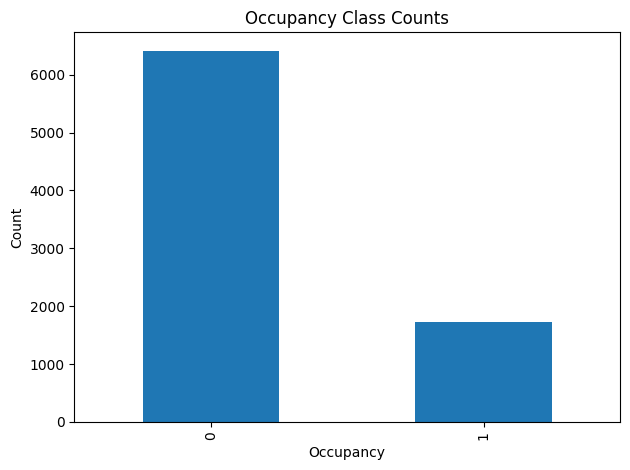

In [315]:
cls_counts = df["Occupancy"].value_counts(dropna=False).sort_index()
cls_ratio = (cls_counts / cls_counts.sum()).round(3)
print("Counts:\n", cls_counts.to_string())
print("\nRatios:\n", cls_ratio.to_string())
cls_counts.plot(kind="bar", title="Occupancy Class Counts")
plt.xlabel("Occupancy"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

### Time-based features & patterns

In [317]:
df.set_index("date", inplace=True)
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = df['dayofweek'] >= 5

by_hour_of_day = (
    df.groupby('hour', as_index=False)['Occupancy']
      .mean()
      .rename(columns={'Occupancy': 'occ_mean'})
)

by_dow_hour = (
    df.groupby(['dayofweek','hour'], as_index=False)['Occupancy']
      .mean()
      .rename(columns={'Occupancy': 'occ_mean'})
)

#### Average Occupancy by Hour of Day


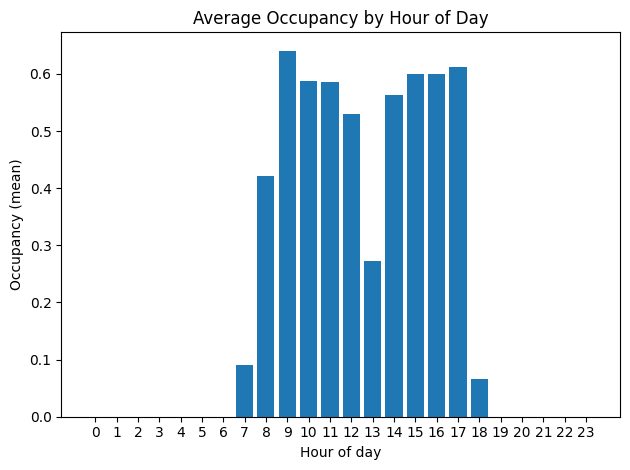

In [318]:
plt.figure()
plt.bar(by_hour_of_day['hour'], by_hour_of_day['occ_mean'])
plt.xticks(range(0, 24))
plt.xlabel('Hour of day')
plt.ylabel('Occupancy (mean)')
plt.title('Average Occupancy by Hour of Day')
plt.tight_layout(); plt.show()

#### Average Occupancy by Hour: Weekday vs Weekend



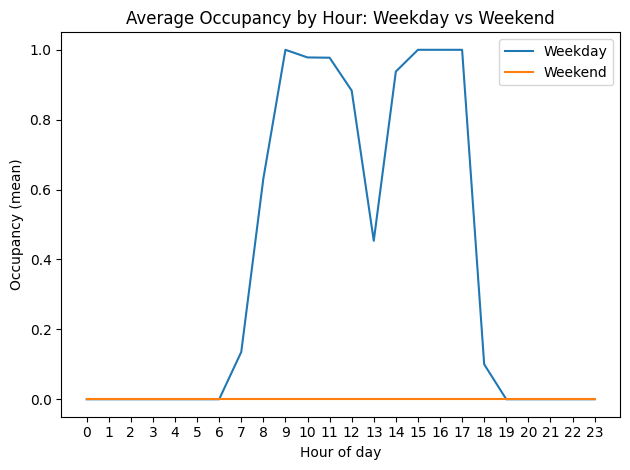

In [319]:
dow_hour_piv = (
    df.groupby(['is_weekend', 'hour'])['Occupancy'].mean()
      .unstack('is_weekend')
      .rename(columns={False: 'Weekday', True: 'Weekend'})
      .reindex(range(24))
)

plt.figure()
plt.plot(dow_hour_piv.index, dow_hour_piv['Weekday'], label='Weekday')
plt.plot(dow_hour_piv.index, dow_hour_piv['Weekend'], label='Weekend')
plt.xticks(range(0,24))
plt.xlabel('Hour of day')
plt.ylabel('Occupancy (mean)')
plt.title('Average Occupancy by Hour: Weekday vs Weekend')
plt.legend(); plt.tight_layout(); plt.show()


#### Mean Occupancy by Day of Week and Hour (Heatmap)


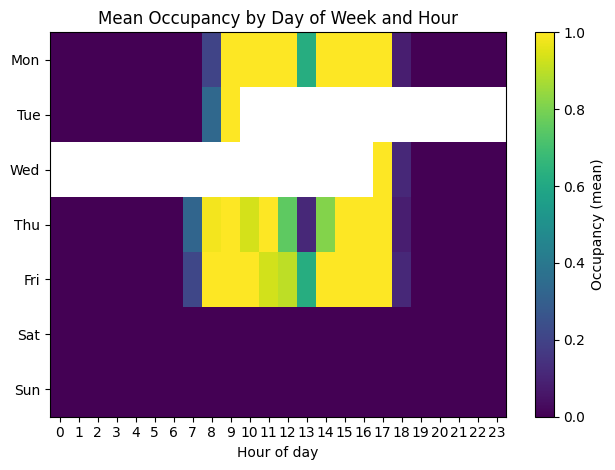

In [320]:
heat = (
    by_dow_hour
    .pivot_table(index='dayofweek', columns='hour', values='occ_mean', aggfunc='mean')
    .reindex(index=range(7), columns=range(24))
)

plt.figure()
im = plt.imshow(heat, aspect='auto', interpolation='nearest')
plt.colorbar(im, label='Occupancy (mean)')
plt.yticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.xticks(ticks=range(0,24,1))
plt.xlabel('Hour of day')
plt.title('Mean Occupancy by Day of Week and Hour')
plt.tight_layout(); plt.show()


In [321]:
roll_window = "30min"
for c in numeric_cols:
    try:
        df[f'{c}_rollmean_{roll_window}'] = df[c].rolling(roll_window).mean()
    except Exception:
        pass
    df[f'{c}_diff_1'] = df[c].diff()

df.head()    

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,hour,dayofweek,is_weekend,Temperature_rollmean_30min,Temperature_diff_1,Humidity_rollmean_30min,Humidity_diff_1,Light_rollmean_30min,Light_diff_1,CO2_rollmean_30min,CO2_diff_1,HumidityRatio_rollmean_30min,HumidityRatio_diff_1
date,,,,,,,,,,,,,,,,,,,
2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1,17,2,False,23.1800,NaN,27.272000,NaN,426.000000,NaN,721.250,NaN,0.004793,NaN
2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1,17,2,False,23.1650,-0.03,27.269750,-0.0045,427.750000,3.5,717.625,-7.25,0.004788,-0.000010
2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1,17,2,False,23.1600,0.00,27.261500,-0.0225,427.166667,-3.5,716.250,-0.50,0.004785,-0.000004
2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1,17,2,False,23.1575,0.00,27.246125,-0.0450,426.875000,0.0,714.250,-5.25,0.004782,-0.000008
2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1,17,2,False,23.1460,-0.05,27.236900,0.0000,426.700000,0.0,712.300,-3.75,0.004777,-0.000015


## Conclusion for `data/datatraining.txt`

- **Dataset**: 8,143 rows × 7 columns (`date`, `Temperature`, `Humidity`, `Light`, `CO2`, `HumidityRatio`, `Occupancy`)
- **Duplicates**: 0 full-row duplicates detected.
- **Missingness**: No data missingness.
- **Class balance**: Occupancy is imbalanced — `0`: 6,414 (78.8%), `1`: 1,729 (21.2%). Evaluation should account for this (beyond raw accuracy).
- **Temporal patterns**:
  - Occupancy is substantially higher during work hours on weekdays; weekends are lower/flatter.
  - Heatmap by day-of-week × hour confirms strong daily/weekly seasonality.
- **Feature signals (qualitative)**: `Light` and `CO2` exhibit shifts around occupied periods; simple rolling means/differences were engineered and are likely predictive.


## ML Pipeline


In [325]:
from dataclasses import dataclass
from pathlib import Path
import json
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibrationDisplay


ARTIFACT_DIR = Path("out_logreg")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42


In [326]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def build_feature_target(df: pd.DataFrame):
    assert 'Occupancy' in df, "Target column 'Occupancy' missing"
    # Basic numeric features
    base_features = [c for c in df.columns if c not in {"Occupancy"} and pd.api.types.is_numeric_dtype(df[c])]
    X = df[base_features].copy()
    y = df['Occupancy'].astype(int).values
    return X, y, base_features


def plot_and_save_curves(y_true, y_proba, prefix: str):
    # ROC
    RocCurveDisplay.from_predictions(y_true, y_proba)
    plt.title(f"ROC Curve - {prefix}")
    plt.tight_layout(); plt.savefig(ARTIFACT_DIR / f"roc_{prefix}.png")
    plt.close()

    # PR
    PrecisionRecallDisplay.from_predictions(y_true, y_proba)
    plt.title(f"PR Curve - {prefix}")
    plt.tight_layout(); plt.savefig(ARTIFACT_DIR / f"pr_{prefix}.png")
    plt.close()

    # Calibration
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10, strategy="quantile")
    plt.figure()
    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0,1],[0,1], '--', color='gray')
    plt.xlabel('Predicted probability')
    plt.ylabel('Observed frequency')
    plt.title(f'Calibration - {prefix}')
    plt.tight_layout(); plt.savefig(ARTIFACT_DIR / f"calibration_{prefix}.png")
    plt.close()


def metrics_dict(y_true, y_proba, y_pred):
    return {
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "f1": float(f1_score(y_true, y_pred)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "brier": float(brier_score_loss(y_true, y_proba)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }


In [327]:
### Load Train/Test Datasets

from pathlib import Path

train_path = Path("data/datatraining.txt")
test1_path = Path("data/datatest.txt")
test2_path = Path("data/datatest2.txt")

# Read CSVs with robust parsing
def read_occ(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if 'date' in df:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.sort_values('date').reset_index(drop=True)
    # Ensure dtypes
    if 'Occupancy' in df:
        df['Occupancy'] = df['Occupancy'].astype(int)   
    return df

train_df = read_occ(train_path)
test1_df = read_occ(test1_path)
test2_df = read_occ(test2_path)

print(train_df.shape, test1_df.shape, test2_df.shape)
train_df.head()


(8143, 7) (2665, 7) (9752, 7)


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


In [328]:
### Build Design Matrices

# Use numeric features + time-derived columns if present
for c in ["hour", "dayofweek", "is_weekend"]:
    if c not in train_df.columns and 'date' in train_df:
        train_df[c] = getattr(train_df['date'].dt, c) if c != 'is_weekend' else (train_df['date'].dt.dayofweek >= 5)
        test1_df[c] = getattr(test1_df['date'].dt, c) if c != 'is_weekend' else (test1_df['date'].dt.dayofweek >= 5)
        test2_df[c] = getattr(test2_df['date'].dt, c) if c != 'is_weekend' else (test2_df['date'].dt.dayofweek >= 5)

X_train, y_train, feat_cols = build_feature_target(train_df)
X_test1, y_test1, _ = build_feature_target(test1_df)
X_test2, y_test2, _ = build_feature_target(test2_df)

feat_cols


['Temperature',
 'Humidity',
 'Light',
 'CO2',
 'HumidityRatio',
 'hour',
 'dayofweek',
 'is_weekend']

In [329]:
### Pipeline, TimeSeries CV and Hyperparameter Tuning

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED, solver="liblinear")),
])

param_grid = {
    "clf__C": np.logspace(-3, 3, 13),
    "clf__penalty": ["l1", "l2"],
}

# Time-series-aware CV on training set only
# Keep blocks contiguous and ordered
cv = TimeSeriesSplit(n_splits=5)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="average_precision",  # robust for class imbalance
    n_jobs=-1,
    verbose=1,
    refit=True,
)

gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
print("Best CV AP:", gs.best_score_)


Fitting 5 folds for each of 26 candidates, totalling 130 fits


/Users/mericmertbulca/DigitalTwinProject/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/mericmertbulca/DigitalTwinProject/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/mericmertbulca/DigitalTwinProject/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/mericmertbulca/DigitalTwinProject/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/mericmertbulca/DigitalTwinProject/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive c

Best params: {'clf__C': np.float64(1.0), 'clf__penalty': 'l2'}
Best CV AP: 0.7820686056890633


In [332]:
### Calibrate the Best Model (Platt scaling via CV on training)

best_pipe = gs.best_estimator_

# Calibrate probabilities using internal CV on training only
calibrator = CalibratedClassifierCV(estimator=best_pipe, method="sigmoid", cv=5)
calibrator.fit(X_train, y_train)

# Save calibrated model
joblib.dump(calibrator, ARTIFACT_DIR / "logreg_calibrated.joblib")
print("Saved:", ARTIFACT_DIR / "logreg_calibrated.joblib")


Saved: out_logreg/logreg_calibrated.joblib


In [333]:
### Evaluate on Test1 (datatest) and Test2 (datatest2)

# Test 1
proba_test1 = calibrator.predict_proba(X_test1)[:, 1]
pred_test1 = (proba_test1 >= 0.5).astype(int)
metrics_test1 = metrics_dict(y_test1, proba_test1, pred_test1)
plot_and_save_curves(y_test1, proba_test1, prefix="test1")
print("Test1 metrics:\n", json.dumps(metrics_test1, indent=2))

# Test 2
proba_test2 = calibrator.predict_proba(X_test2)[:, 1]
pred_test2 = (proba_test2 >= 0.5).astype(int)
metrics_test2 = metrics_dict(y_test2, proba_test2, pred_test2)
plot_and_save_curves(y_test2, proba_test2, prefix="test2")
print("\nTest2 metrics:\n", json.dumps(metrics_test2, indent=2))

# Save metrics
with open(ARTIFACT_DIR / "metrics.json", "w") as f:
    json.dump({"test1": metrics_test1, "test2": metrics_test2}, f, indent=2)
print("Saved:", ARTIFACT_DIR / "metrics.json")


Test1 metrics:
 {
  "roc_auc": 0.9915744812213934,
  "pr_auc": 0.973287255954922,
  "f1": 0.9719719719719719,
  "accuracy": 0.9789868667917448,
  "brier": 0.0187840114266325,
  "confusion_matrix": [
    [
      1638,
      55
    ],
    [
      1,
      971
    ]
  ]
}

Test2 metrics:
 {
  "roc_auc": 0.9963933100291718,
  "pr_auc": 0.9779939952046418,
  "f1": 0.9859632139399807,
  "accuracy": 0.9940525020508614,
  "brier": 0.009340847225278445,
  "confusion_matrix": [
    [
      7657,
      46
    ],
    [
      12,
      2037
    ]
  ]
}
Saved: out_logreg/metrics.json


In [334]:
### Persist Artifacts

# Save the feature list and best params
artifact = {
    "features": feat_cols,
    "best_params": gs.best_params_,
}
with open(ARTIFACT_DIR / "model_info.json", "w") as f:
    json.dump(artifact, f, indent=2)

# Save pipeline (pre-calibration) and calibrated wrapper
joblib.dump(gs.best_estimator_, ARTIFACT_DIR / "logreg_best_pipeline.joblib")
joblib.dump(calibrator, ARTIFACT_DIR / "logreg_calibrated.joblib")

print("Artifacts saved in", ARTIFACT_DIR)


Artifacts saved in out_logreg


In [336]:
### Show Accuracies for Test1 and Test2

import json
from pathlib import Path

metrics_path = Path("out_logreg/metrics.json")
with open(metrics_path, "r") as f:
    m = json.load(f)

print("datatest.txt (test1) accuracy:", m["test1"]["accuracy"])  # test1
print("datatest2.txt (test2) accuracy:", m["test2"]["accuracy"])  # test2


datatest.txt (test1) accuracy: 0.9789868667917448
datatest2.txt (test2) accuracy: 0.9940525020508614


In [337]:
### Leakage/Overfitting Diagnostics

from sklearn.utils import shuffle as sk_shuffle

# 1) Ensure target not in features
assert 'Occupancy' not in feat_cols, "Leakage: target present in features!"
print("Feature list OK (no target):", len(feat_cols), "features")

# 2) Check datetime overlap between train and tests
if 'date' in train_df and 'date' in test1_df and 'date' in test2_df:
    overlap_1 = set(train_df['date']).intersection(set(test1_df['date']))
    overlap_2 = set(train_df['date']).intersection(set(test2_df['date']))
    print("Datetime overlaps -> train vs test1:", len(overlap_1), "; train vs test2:", len(overlap_2))

# 3) Shuffled-label baseline: model should perform ~chance/majority if labels permuted
X_train_arr, y_train_arr = X_train.values, y_train.copy()
y_train_shuffled = sk_shuffle(y_train_arr, random_state=SEED)
pipe_baseline = gs.best_estimator_
pipe_baseline.fit(X_train_arr, y_train_shuffled)
proba_test1_shuf = pipe_baseline.predict_proba(X_test1)[:, 1]
acc_test1_shuf = accuracy_score(y_test1, (proba_test1_shuf >= 0.5).astype(int))
proba_test2_shuf = pipe_baseline.predict_proba(X_test2)[:, 1]
acc_test2_shuf = accuracy_score(y_test2, (proba_test2_shuf >= 0.5).astype(int))
print("Shuffled-label baseline accuracies -> test1:", round(acc_test1_shuf, 4), ", test2:", round(acc_test2_shuf, 4))

# 4) Sensitivity to removing time-derived features
sensor_cols = [c for c in feat_cols if c not in {"hour", "dayofweek", "is_weekend"}]
Xtr_s, Xte1_s, Xte2_s = X_train[sensor_cols], X_test1[sensor_cols], X_test2[sensor_cols]
pipe_sensors = gs.best_estimator_
pipe_sensors.fit(Xtr_s, y_train)
acc_test1_s = accuracy_score(y_test1, (pipe_sensors.predict_proba(Xte1_s)[:, 1] >= 0.5).astype(int))
acc_test2_s = accuracy_score(y_test2, (pipe_sensors.predict_proba(Xte2_s)[:, 1] >= 0.5).astype(int))
print("Accuracies without time features -> test1:", round(acc_test1_s, 4), ", test2:", round(acc_test2_s, 4))


Feature list OK (no target): 8 features
Datetime overlaps -> train vs test1: 0 ; train vs test2: 0
Shuffled-label baseline accuracies -> test1: 0.5051 , test2: 0.1545
Accuracies without time features -> test1: 0.9786 , test2: 0.991


/Users/mericmertbulca/DigitalTwinProject/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/mericmertbulca/DigitalTwinProject/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [348]:
### Predict a Single Row with the Trained Model

import json
import joblib
import pandas as pd
from pathlib import Path

# Load calibrated model and feature list
calibrated_model = joblib.load(Path("out_logreg/logreg_calibrated.joblib"))
with open(Path("out_logreg/model_info.json"), "r") as f:
    model_info = json.load(f)
feat_cols_in_order = model_info["features"]

# Helper: build a single-row DataFrame from raw inputs
# Provide inputs in original units/columns; time features are derived if date is present

def make_single_row_df(
    date: str | None = None,
    Temperature: float | None = None,
    Humidity: float | None = None,
    Light: float | None = None,
    CO2: float | None = None,
    HumidityRatio: float | None = None,
):
    row = {
        "Temperature": Temperature,
        "Humidity": Humidity,
        "Light": Light,
        "CO2": CO2,
        "HumidityRatio": HumidityRatio,
    }
    df_row = pd.DataFrame([row])

    if date is not None:
        dt = pd.to_datetime(date, errors="coerce")
        df_row["hour"] = dt.hour
        df_row["dayofweek"] = dt.dayofweek
        df_row["is_weekend"] = dt.dayofweek >= 5

    # ensure all expected features exist
    for c in feat_cols_in_order:
        if c not in df_row.columns:
            df_row[c] = 0

    # order columns as during training
    df_row = df_row[feat_cols_in_order]
    return df_row

# 0,537,0.0051614179748336,0
# Example 1: From explicit values
example_row = make_single_row_df(
    date="2015-02-11 09:30:00",
    Temperature=19.89,
    Humidity=35.9,
    Light=0.537,
    CO2=749.2,
    HumidityRatio=0.0051614179748336,
)
proba = calibrated_model.predict_proba(example_row)[:, 1][0]
pred = int(proba >= 0.5)
print({"proba_occupied": round(float(proba), 4), "predicted_occupancy": pred})

# Example 2: Use a real row from test1_df (drop target)
if 'test1_df' in globals():
    sample = test1_df.iloc[[0]].drop(columns=["Occupancy"]) if "Occupancy" in test1_df.columns else test1_df.iloc[[0]].copy()
    # add time features if not present
    if 'date' in sample.columns:
        sample["hour"] = sample["date"].dt.hour
        sample["dayofweek"] = sample["date"].dt.dayofweek
        sample["is_weekend"] = sample["date"].dt.dayofweek >= 5
    for c in feat_cols_in_order:
        if c not in sample.columns:
            sample[c] = 0
    sample = sample[feat_cols_in_order]
    p = calibrated_model.predict_proba(sample)[:, 1][0]
    yhat = int(p >= 0.5)
    print({"test1_row0_proba": round(float(p), 4), "test1_row0_pred": yhat})


{'proba_occupied': 0.0164, 'predicted_occupancy': 0}
{'test1_row0_proba': 0.9685, 'test1_row0_pred': 1}
